# Problem Statement 

**Hospitals generate large amounts of structured data from patient visits, admissions, and billing transactions.
While most records follow expected clinical and financial patterns, some may represent anomalies such as incorrect charges, 
fraudulent claims, unusual patient–diagnosis mismatches, or abnormal physician billing behavior**.

### Data Description

| Column Name              | Description                                                                        | Example Values                            |
| ------------------------ | ---------------------------------------------------------------------------------- | ----------------------------------------- |
| **patient\_id**          | Unique identifier assigned to each patient.                                        | `P12345`                                  |
| **gender**               | Gender of the patient.                                                             | `Male`, `Female`, `Other`                 |
| **age**                  | Age of the patient (in years).                                                     | `35`, `62`                                |
| **visit\_date**          | Date when the patient visited the hospital/clinic.                                 | `2023-07-14`                              |
| **department**           | Hospital department where the patient was seen.                                    | `Cardiology`, `Oncology`, `Emergency`     |
| **physician\_id**        | Unique identifier for the attending physician.                                     | `DR4567`                                  |
| **diagnosis**            | Primary diagnosis assigned during the visit (ICD code or text).                    | `Hypertension`, `Diabetes Mellitus`       |
| **visit\_type**          | Type of visit.                                                                     | `Outpatient`, `Inpatient`, `Emergency`    |
| **visit\_reason**        | Reason for the visit as stated by the patient or recorded.                         | `Chest pain`, `Routine checkup`           |
| **appointment\_id**      | Unique identifier for the appointment (helps detect duplicate or multiple claims). | `A78901`                                  |
| **is\_emergency**        | Indicates if the visit was marked as an emergency.                                 | `Yes/No` or `1/0`                         |
| **insurance\_id**        | Unique identifier of the patient’s insurance provider.                             | `INS8765`                                 |
| **payer\_name**          | Name of the payer/insurance company responsible for covering charges.              | `Medicare`, `BlueCross`, `Private`        |
| **payer\_type**          | Type of payer (public, private, self-pay, government).                             | `Private`, `Government`, `Self`           |
| **claim\_status**        | Current status of the insurance claim.                                             | `Pending`, `Approved`, `Rejected`, `Paid` |
| **charge\_amount\_USD**  | Total charges billed for the visit (in US Dollars).                                | `500.00`, `3500.75`                       |
| **payment\_amount\_USD** | Actual payment received from payer/patient (in US Dollars).                        | `450.00`, `0.00`                          |
| **admission\_date**      | Date of hospital admission (for inpatients).                                       | `2023-07-12`                              |
| **discharge\_date**      | Date of hospital discharge (for inpatients).                                       | `2023-07-15`                              |


In [257]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings("ignore")

In [258]:
df=pd.read_csv('Hospital_billing.csv')
df.head()

,patient_id,gender,age,visit_date,department,physician_id,diagnosis,visit_type,visit_reason,appointment_id,is_emergency,insurance_id,payer_name,payer_type,claim_status,charge_amount_USD,payment_amount_USD,admission_date,discharge_date
0,154669,Male,43,05-11-2024,Cardiology,30927,Hypertension,Outpatient,NaN,A00000,Yes,INS-MMIAPD,Flores-Allen,Government,Submitted,247,0,NaN,NaN
1,144776,Female,56,15-12-2024,Cardiology,14816,Hypertension,Outpatient,Chest Pain,A00001,No,INS-M2HVS3,"Anderson, Oconnell and Yates",Insurance,Approved,296,0,NaN,NaN
2,217503,Male,49,02-01-2024,Orthopedics,73819,Back Pain,Inpatient,Surgery Follow-up,A00002,No,INS-GMOCQU,Jackson-Hubbard,Government,Denied,1240,992,02-01-2024,26-01-2024
3,174851,Male,8,29-06-2024,Pediatrics,81325,Asthma,Outpatient,Fever,A00003,No,NaN,Self-pay,Self-pay,Paid,43,43,NaN,NaN
4,193134,Female,39,21-11-2024,Cardiology,10046,Heart Failure,Outpatient,Chest Pain,A00004,Yes,NaN,Gonzalez Group,Insurance,Approved,219,0,NaN,NaN


In [259]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   patient_id          6000 non-null   int64 
 1   gender              6000 non-null   object
 2   age                 6000 non-null   int64 
 3   visit_date          6000 non-null   object
 4   department          6000 non-null   object
 5   physician_id        6000 non-null   int64 
 6   diagnosis           5576 non-null   object
 7   visit_type          6000 non-null   object
 8   visit_reason        5601 non-null   object
 9   appointment_id      6000 non-null   object
 10  is_emergency        6000 non-null   object
 11  insurance_id        3697 non-null   object
 12  payer_name          5598 non-null   object
 13  payer_type          6000 non-null   object
 14  claim_status        6000 non-null   object
 15  charge_amount_USD   6000 non-null   int64 
 16  payment_amount_USD  6000

In [260]:
df.isna().sum()

patient_id               0
gender                   0
age                      0
visit_date               0
department               0
physician_id             0
diagnosis              424
visit_type               0
visit_reason           399
appointment_id           0
is_emergency             0
insurance_id          2303
payer_name             402
payer_type               0
claim_status             0
charge_amount_USD        0
payment_amount_USD       0
admission_date        2988
discharge_date        2988
dtype: int64

In [261]:
## The columns  diagnosis , visit_reason  , payer_name admission_date discharge_date , will be impute with the mode 
## The columns insurance_id  of missing value will be impute with the 'missing'

In [262]:
# Columns to impute with mode
mode_cols = ["diagnosis", "visit_reason", "payer_name", "admission_date", "discharge_date"]

for col in mode_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Impute insurance_id with "missing"
df["insurance_id"].fillna("missing", inplace=True)


In [263]:
df.isna().sum()

patient_id            0
gender                0
age                   0
visit_date            0
department            0
physician_id          0
diagnosis             0
visit_type            0
visit_reason          0
appointment_id        0
is_emergency          0
insurance_id          0
payer_name            0
payer_type            0
claim_status          0
charge_amount_USD     0
payment_amount_USD    0
admission_date        0
discharge_date        0
dtype: int64

In [264]:
df.describe()

,patient_id,age,physician_id,charge_amount_USD,payment_amount_USD
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,165320.868833,37.539333,54477.194833,349.127000,142.259333
std,31664.496141,20.092670,25957.515724,625.756656,502.622747
min,110015.000000,1.000000,10002.000000,40.000000,0.000000
25%,137784.000000,19.000000,31694.250000,131.750000,0.000000
50%,165830.500000,40.000000,54671.500000,177.000000,0.000000
75%,192591.250000,54.000000,76971.500000,282.000000,141.000000
max,219998.000000,80.000000,99954.000000,11940.000000,9552.000000


In [265]:
df['admission_date'] = pd.to_datetime(df['admission_date'],format='%d-%m-%Y')
df['discharge_date'] = pd.to_datetime(df['discharge_date'],format='%d-%m-%Y')
df['visit_date'] = pd.to_datetime(df['visit_date'],format='%d-%m-%Y')

**In this dataset we consider as the Hospital side as billing Anomaly detection so we try understand the datset with the charge_amount_USD and start find the analysis**


## Unvivariate analysis 

In [268]:
cate=df.select_dtypes(include=['object','category']).columns
cate

Index(['gender', 'department', 'diagnosis', 'visit_type', 'visit_reason',
       'appointment_id', 'is_emergency', 'insurance_id', 'payer_name',
       'payer_type', 'claim_status'],
      dtype='object')

In [269]:
num=df.select_dtypes(include=['int64','float']).columns
num


Index(['patient_id', 'age', 'physician_id', 'charge_amount_USD',
       'payment_amount_USD'],
      dtype='object')

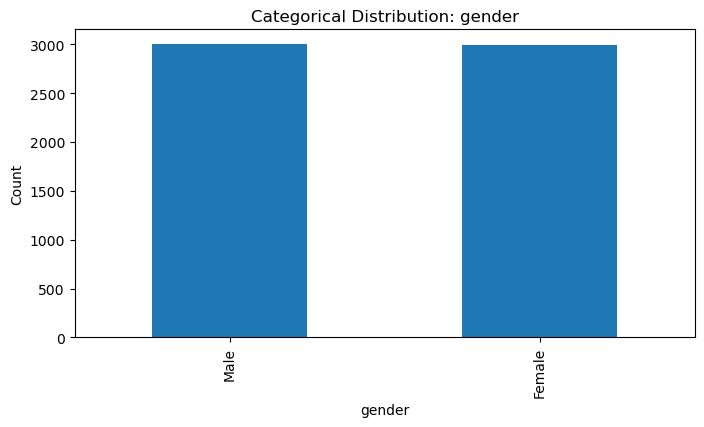

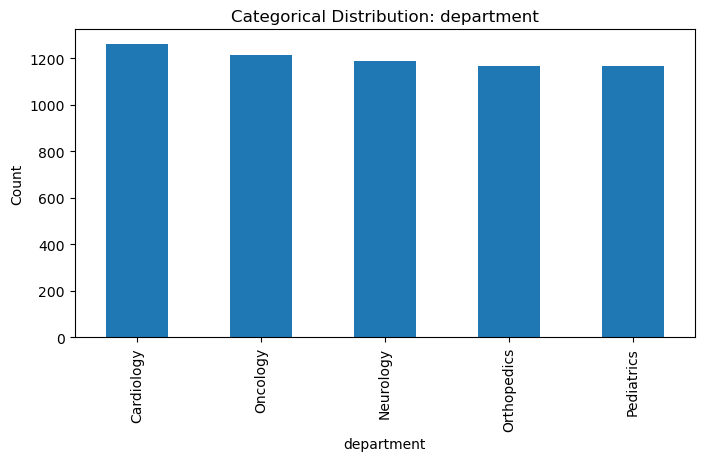

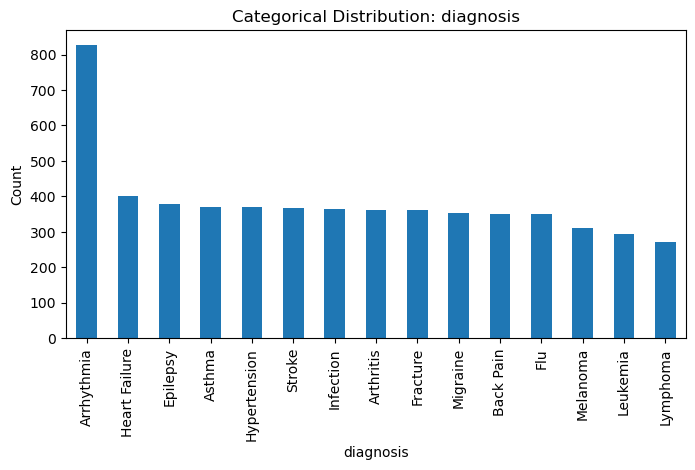

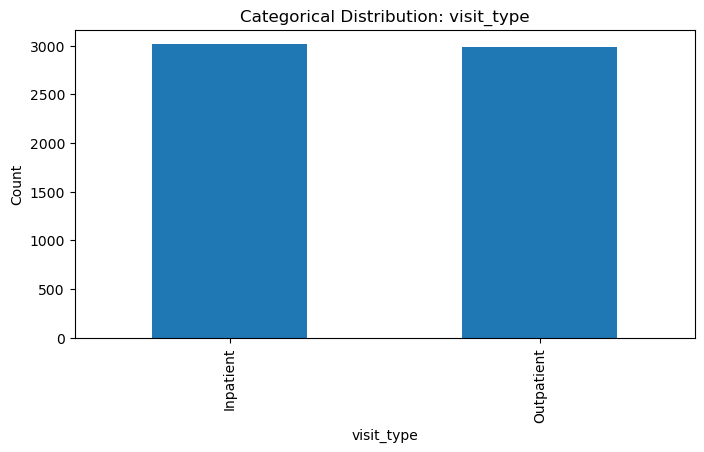

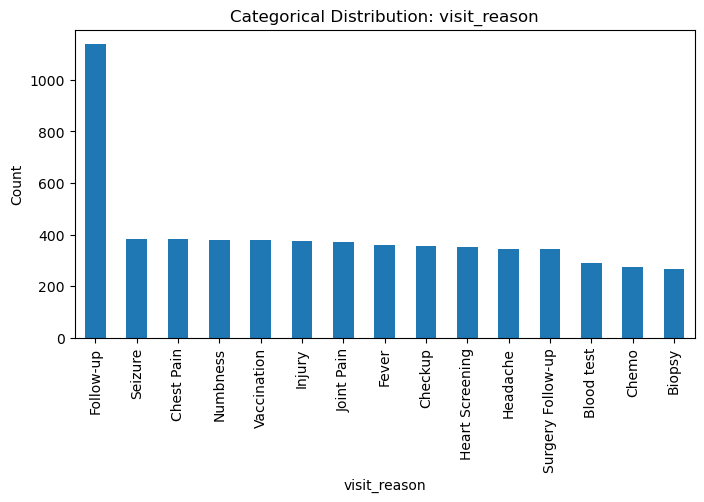

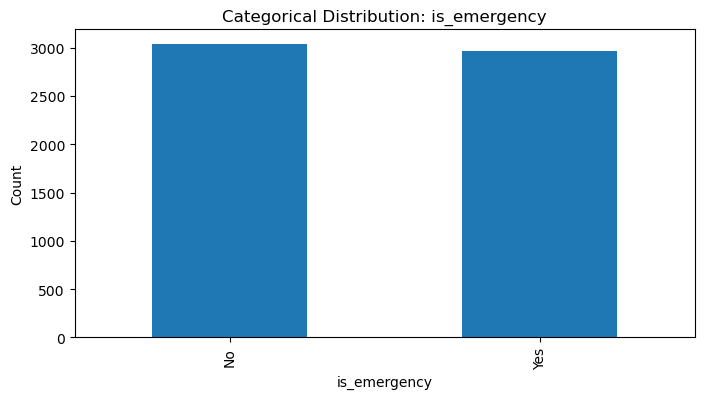

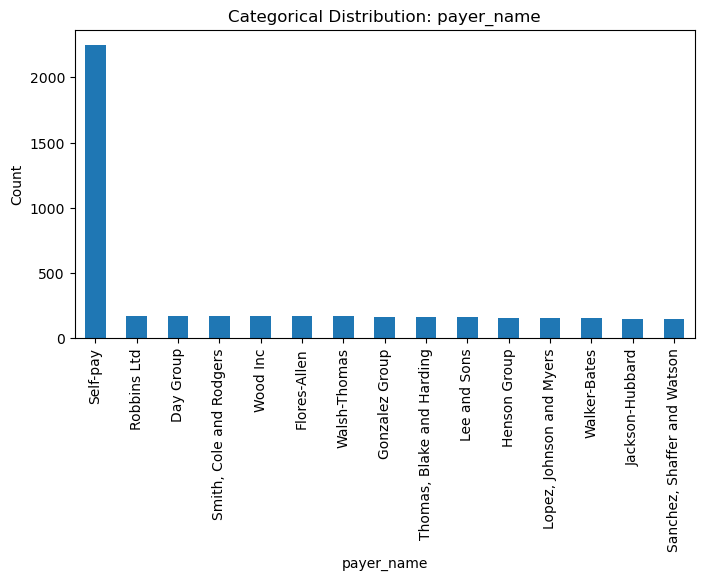

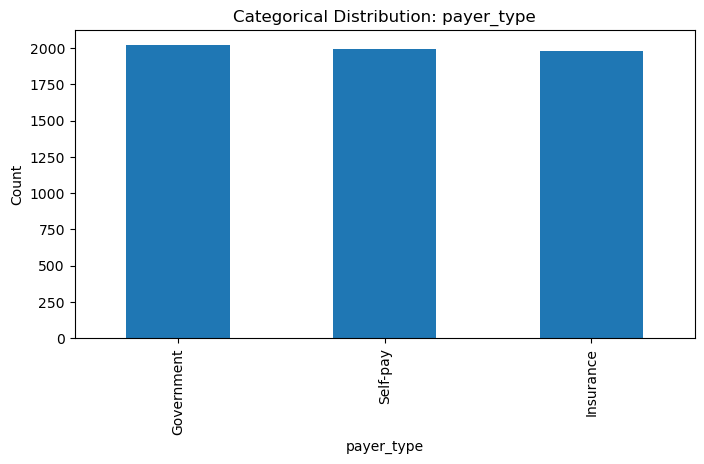

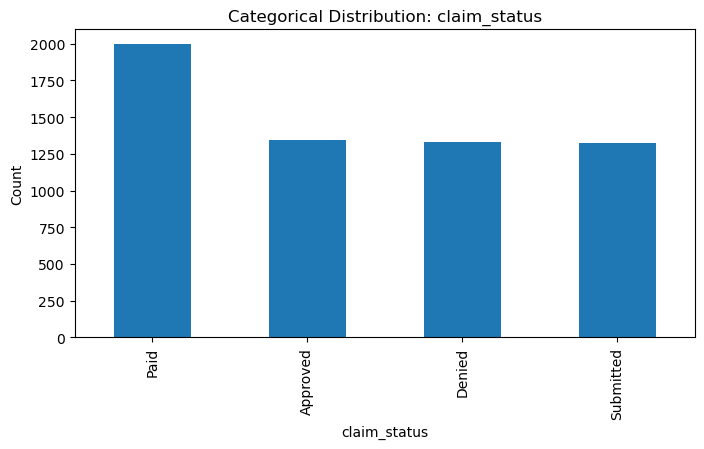

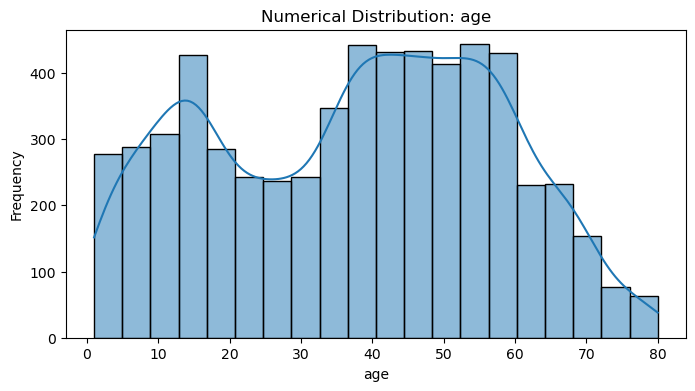

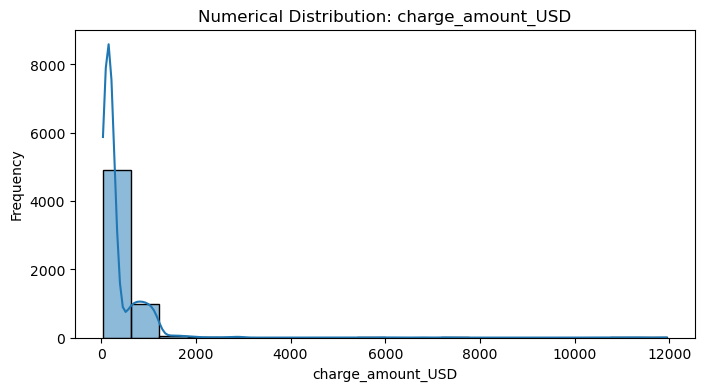

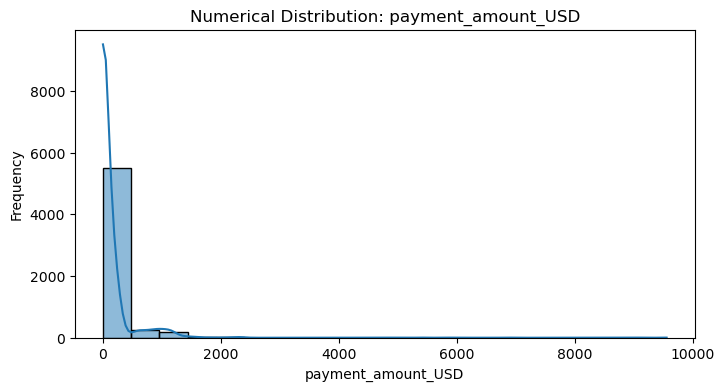

In [270]:

import seaborn as sns

def univariate_analysis(df):
    # Separate by data type
    categorical = df[['gender', 'department', 'diagnosis', 'visit_type', 'visit_reason', 'is_emergency',  'payer_name',
       'payer_type', 'claim_status']]
    numerical = df[['age','charge_amount_USD','payment_amount_USD']]
    
    # --- Categorical Variables ---
    for col in categorical:
        plt.figure(figsize=(8,4))
        df[col].value_counts(dropna=False).head(15).plot(kind="bar")
        plt.title(f"Categorical Distribution: {col}")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()

    # --- Numerical Variables ---
    for col in numerical:
        plt.figure(figsize=(8,4))
        sns.histplot(df[col], kde=True, bins=20)
        plt.title(f"Numerical Distribution: {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()


# Run analysis
univariate_analysis(df)


**Key Findings**

- The age distribution is multimodal and slightly right-skewed, with a strong concentration in the 20–50 years range.

- Arrhythmia emerges as the most frequently diagnosed condition. 

- Follow-up visits account for over 1,000 recorded visit reasons.

- A majority of patients fall under the self-pay category.

- The distribution of Charge Amount (USD) is right-skewed, mirroring the pattern observed in Payer Amount (USD).

## Bi-Variate Analysis 
**Our Intrest in finding the anomalies in the hospital billings so we consider the charge_amount_usd is base attribute**

In [273]:
categorical = df[['gender', 'department', 'diagnosis', 'visit_type', 'visit_reason', 'is_emergency',  'payer_name', 'payer_type', 'claim_status']] 
numerical = df[['age','charge_amount_USD','payment_amount_USD']]

In [274]:
categorical

,gender,department,diagnosis,visit_type,visit_reason,is_emergency,payer_name,payer_type,claim_status
0,Male,Cardiology,Hypertension,Outpatient,Follow-up,Yes,Flores-Allen,Government,Submitted
1,Female,Cardiology,Hypertension,Outpatient,Chest Pain,No,"Anderson, Oconnell and Yates",Insurance,Approved
2,Male,Orthopedics,Back Pain,Inpatient,Surgery Follow-up,No,Jackson-Hubbard,Government,Denied
3,Male,Pediatrics,Asthma,Outpatient,Fever,No,Self-pay,Self-pay,Paid
4,Female,Cardiology,Heart Failure,Outpatient,Chest Pain,Yes,Gonzalez Group,Insurance,Approved
...,...,...,...,...,...,...,...,...,...
5995,Male,Pediatrics,Infection,Inpatient,Fever,No,Merritt-Flynn,Government,Denied
5996,Male,Pediatrics,Asthma,Outpatient,Follow-up,Yes,Self-pay,Self-pay,Paid
5997,Female,Orthopedics,Back Pain,Outpatient,Follow-up,Yes,Self-pay,Self-pay,Paid
5998,Male,Neurology,Epilepsy,Outpatient,Headache,No,"Smith, Cole and Rodgers",Insurance,Approved


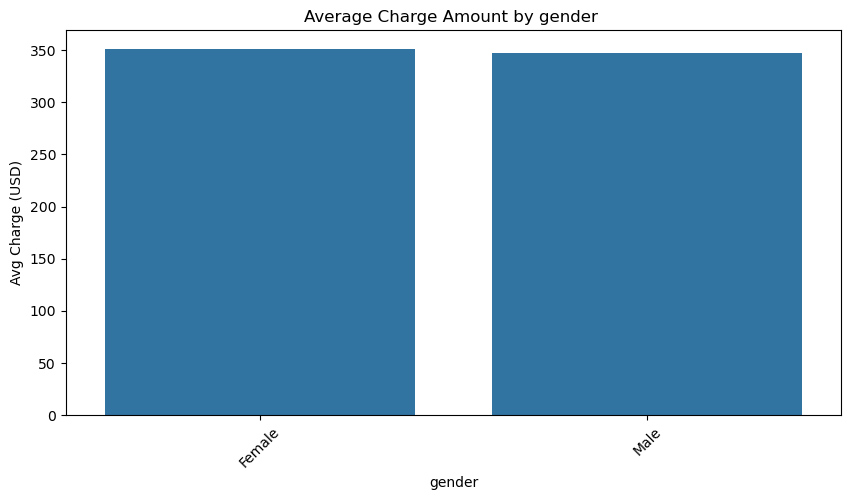

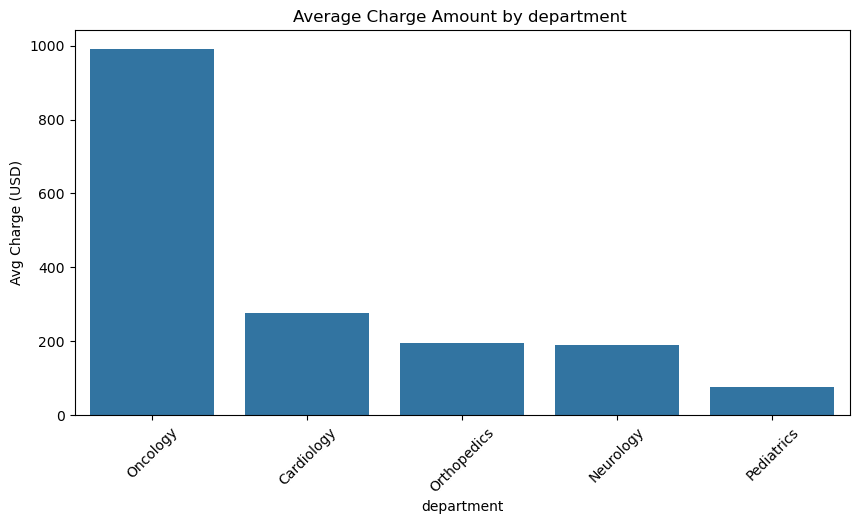

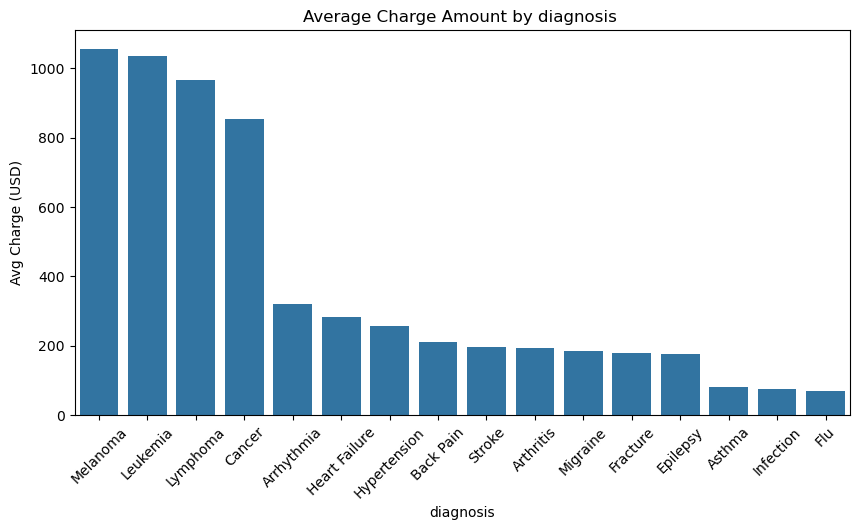

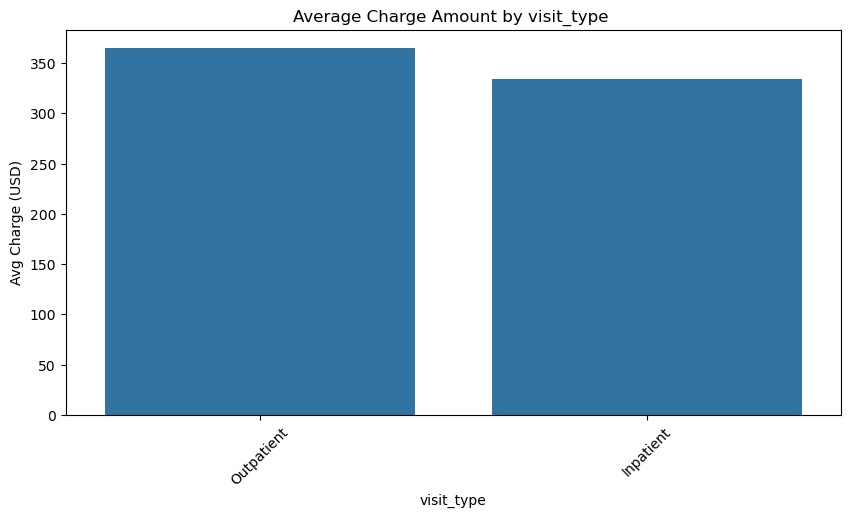

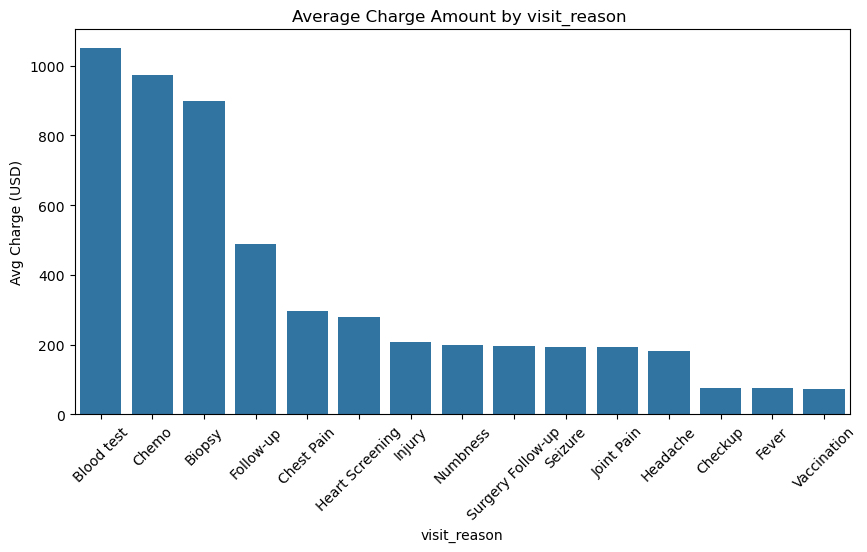

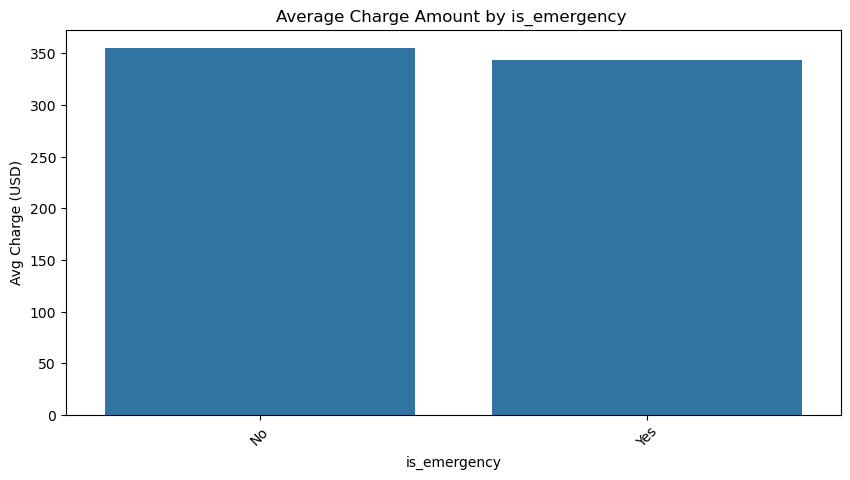

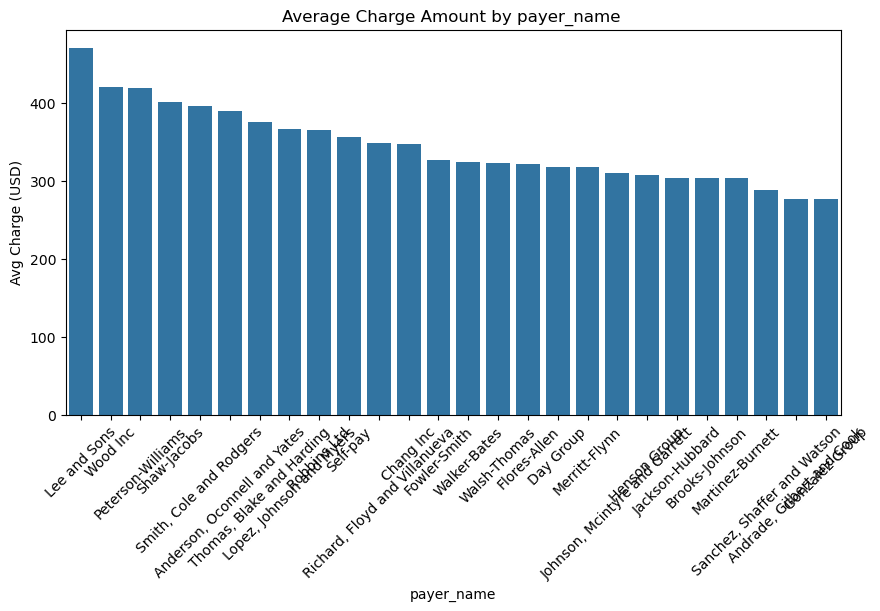

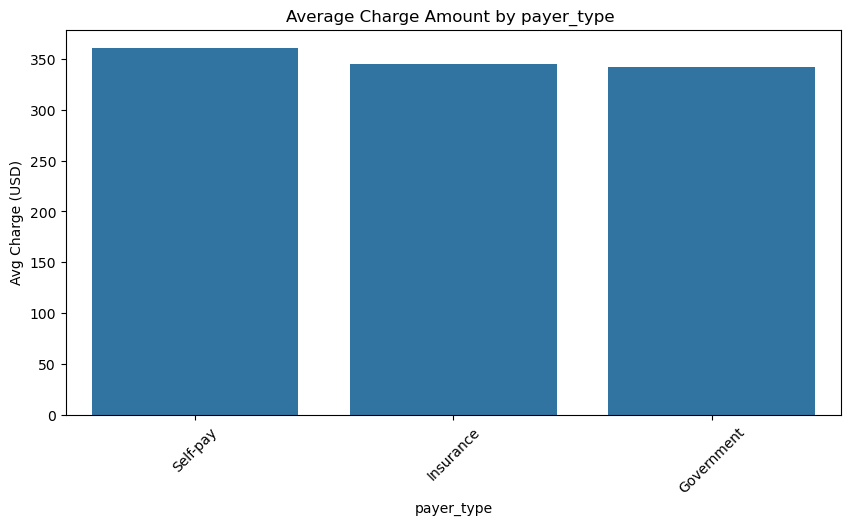

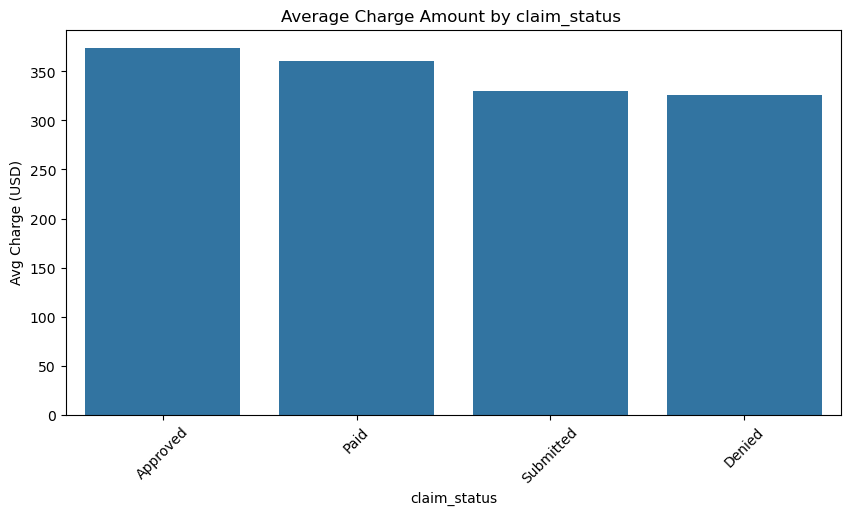

In [275]:
for col in categorical.columns:
    plt.figure(figsize=(10,5))
    avg_charges = df.groupby(col)['charge_amount_USD'].mean().sort_values(ascending=False)#.head(10)
    sns.barplot(x=avg_charges.index, y=avg_charges.values)
    plt.xticks(rotation=45)
    plt.title(f'Average Charge Amount by {col} ')#(Top 10)')
    plt.ylabel("Avg Charge (USD)")
    plt.show()


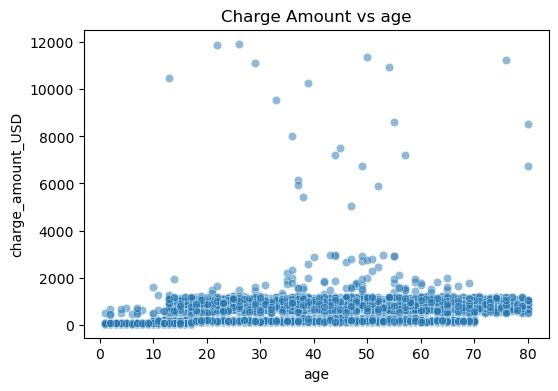

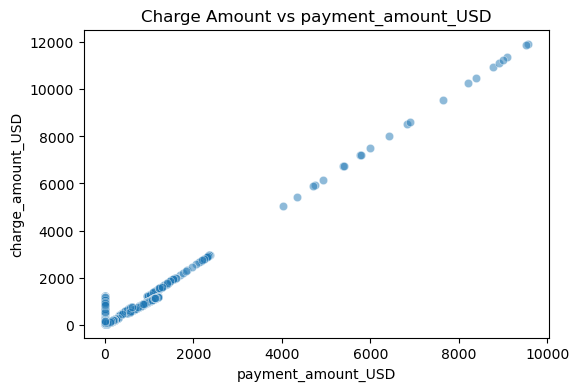

In [276]:
for col in ['age','payment_amount_USD']:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=col, y='charge_amount_USD', data=df, alpha=0.5)
    plt.title(f'Charge Amount vs {col}')
    plt.show()


**Important Insights on Charge Amount** 

- Oncology have the significance higher average charge amount
- Patients diagnosed with Melanoma, Leukemia, Lymphoma, and Cancer incur the highest average charges, exceeding $850–$1000.
- Patients visiting for Blood Tests, Chemotherapy, and Biopsies incur the highest average charges (around $900–$1,050).

**Before conducting Multivariate Analysis, an ANOVA test will be performed to identify significant relationships among the existing features.**

In [279]:
from scipy import stats

target = "charge_amount_USD"

categorical_cols = df[['gender', 'department', 'diagnosis', 'visit_type', 'visit_reason', 'is_emergency',  'payer_name','payer_type', 'claim_status']]
numeric_cols = df[[ 'age','payment_amount_USD']]

results = []

# ANOVA for categorical features
for col in categorical_cols:
    groups = [group[target].values 
              for name, group in df.groupby(col) if len(group) > 1]
    
    if len(groups) > 1:
        f_stat, p_val = stats.f_oneway(*groups)
        results.append((col, "Categorical", f_stat, p_val))

# Correlation for numeric features
for col in numeric_cols:
    corr, p_val = stats.pearsonr(df[col], df[target])
    results.append((col, "Numeric", corr, p_val))

# Create results DataFrame
anova_corr_results = pd.DataFrame(results, columns=["Feature", "Type", "Statistic", "p-value"])
anova_corr_results["Significant (p<0.05)"] = anova_corr_results["p-value"] < 0.05

# Sort by p-value (strongest relationships first)
anova_corr_results = anova_corr_results.sort_values("p-value")

(anova_corr_results)

,Feature,Type,Statistic,p-value,Significant (p<0.05)
1,department,Categorical,578.329262,0.000000e+00,True
2,diagnosis,Categorical,138.740947,0.000000e+00,True
10,payment_amount_USD,Numeric,0.882192,0.000000e+00,True
4,visit_reason,Categorical,112.983596,1.416678e-291,True
9,age,Numeric,0.173537,8.809441e-42,True
3,visit_type,Categorical,3.714243,5.399726e-02,False
8,claim_status,Categorical,1.963188,1.172309e-01,False
5,is_emergency,Categorical,0.519676,4.710080e-01,False
6,payer_name,Categorical,0.947715,5.372505e-01,False
7,payer_type,Categorical,0.528685,5.894067e-01,False


Note : In business terminial we have to consider all columns and then perform the anomaly detection but current we have less confidence to build isolation forest on the all feature because we don't will this work correctly or not and no evaluation metric how to build now ?

In [281]:
cate=df.select_dtypes(include=['object','category']).columns
cate

Index(['gender', 'department', 'diagnosis', 'visit_type', 'visit_reason',
       'appointment_id', 'is_emergency', 'insurance_id', 'payer_name',
       'payer_type', 'claim_status'],
      dtype='object')

In [282]:
Num=df.select_dtypes(include=['int64','float']).columns
Num

Index(['patient_id', 'age', 'physician_id', 'charge_amount_USD',
       'payment_amount_USD'],
      dtype='object')

In [283]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder

# Assuming df is your dataframe and charge_amount_USD is the target
target = 'charge_amount_USD'

# Define categorical and numeric columns
categorical_cols = ['gender', 'department', 'diagnosis', 'visit_type', 
                    'visit_reason', 'is_emergency', 'payer_name', 
                    'payer_type', 'claim_status']

numeric_cols = ['age', 'payment_amount_USD']  # exclude target

# --- Mutual Information for Categorical vs Numeric target ---
mi_scores = {}
for col in categorical_cols:
    le = LabelEncoder()
    encoded = le.fit_transform(df[col].astype(str))  # encode categorical
    mi = mutual_info_regression(encoded.reshape(-1,1), df[target], random_state=42)
    mi_scores[col] = mi[0]

# --- Correlation for Numeric vs Numeric target ---
corr_scores = {}
for col in numeric_cols:
    corr = df[col].corr(df[target], method='spearman')  # spearman handles monotonic
    corr_scores[col] = abs(corr)

# Combine results into single dataframe
feature_importance = pd.DataFrame({
    "Feature": list(mi_scores.keys()) + list(corr_scores.keys()),
    "Score": list(mi_scores.values()) + list(corr_scores.values())
}).sort_values(by="Score", ascending=False).reset_index(drop=True)

print(feature_importance)


               Feature     Score
0           department  1.167023
1            diagnosis  1.019347
2         visit_reason  0.955158
3                  age  0.486870
4   payment_amount_USD  0.193955
5         claim_status  0.003812
6         is_emergency  0.002141
7           visit_type  0.000902
8               gender  0.000000
9           payer_name  0.000000
10          payer_type  0.000000


**Since we are performing anomaly detection at the hospital level, we consider the following attributes:**

- department

- diagnosis

- visit_reason

- age

- is_emergency

- payment_amount_USD

- claim_status (optional)

- visit_type (optional)

- gender (optional)

- charge_amount_USD

## Multivariate Analysis


**Numberic Attribute**

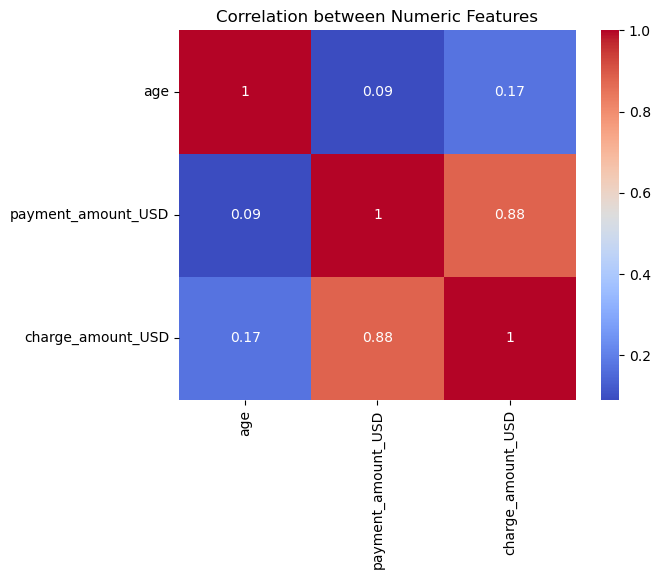

In [287]:
numeric_cols = ['age', 'payment_amount_USD', 'charge_amount_USD']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation between Numeric Features')
plt.show()


## Build a model on the key Feature with Isolation forest 

In [289]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import IsolationForest
from sklearn.pipeline import Pipeline

# Define columns
numerical_cols = ['age', 'payment_amount_USD', 'charge_amount_USD']
categorical_cols = ['department', 'diagnosis', 'visit_reason', 
                    'is_emergency', 'claim_status', 'visit_type', 'gender']

In [290]:
df[numerical_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   age                 6000 non-null   int64
 1   payment_amount_USD  6000 non-null   int64
 2   charge_amount_USD   6000 non-null   int64
dtypes: int64(3)
memory usage: 140.8 KB


In [291]:
df[categorical_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   department    6000 non-null   object
 1   diagnosis     6000 non-null   object
 2   visit_reason  6000 non-null   object
 3   is_emergency  6000 non-null   object
 4   claim_status  6000 non-null   object
 5   visit_type    6000 non-null   object
 6   gender        6000 non-null   object
dtypes: object(7)
memory usage: 328.3+ KB


In [292]:
# Preprocessing for categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    remainder='passthrough'  # numerical columns stay as-is
)

# Build pipeline
pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('anomaly_detector', IsolationForest(
        n_estimators=100, contamination=0.01, random_state=42))
])

# Fit the pipeline on the selected columns
pipeline.fit(df[numerical_cols + categorical_cols])

# Predict anomalies (-1 = anomaly, 1 = normal)
df['anomaly'] = pipeline.predict(df[numerical_cols + categorical_cols])

# Inspect anomalies
print(df['anomaly'].value_counts())


anomaly
 1    5940
-1      60
Name: count, dtype: int64


In [293]:
(df[numerical_cols + categorical_cols])

,age,payment_amount_USD,charge_amount_USD,department,diagnosis,visit_reason,is_emergency,claim_status,visit_type,gender
0,43,0,247,Cardiology,Hypertension,Follow-up,Yes,Submitted,Outpatient,Male
1,56,0,296,Cardiology,Hypertension,Chest Pain,No,Approved,Outpatient,Female
2,49,992,1240,Orthopedics,Back Pain,Surgery Follow-up,No,Denied,Inpatient,Male
3,8,43,43,Pediatrics,Asthma,Fever,No,Paid,Outpatient,Male
4,39,0,219,Cardiology,Heart Failure,Chest Pain,Yes,Approved,Outpatient,Female
...,...,...,...,...,...,...,...,...,...,...
5995,2,0,75,Pediatrics,Infection,Fever,No,Denied,Inpatient,Male
5996,9,56,56,Pediatrics,Asthma,Follow-up,Yes,Paid,Outpatient,Male
5997,44,122,122,Orthopedics,Back Pain,Follow-up,Yes,Paid,Outpatient,Female
5998,60,0,122,Neurology,Epilepsy,Headache,No,Approved,Outpatient,Male


**How can we ensure that an Isolation Forest model is functioning correctly when we don’t have a clear evaluation metric?**

**Which statistical or analytical methods can help reduce errors from a business perspective?**

**If the model is deployed without proper validation, what could happen when data drift or changes in variable distributions occur over time?**

**How can we penalize errors caused by drift or variability changes during deployment, and what actions should be taken to handle them?**

**Can you list any analytical or monitoring methods that can address these issues effectively?**

**What’s the impact of deploying a model without proper evaluation or validation?**

**How do we monitor deployed models for both performance degradation and business KPIs?**

**Which analytic methods or dashboards are effective for post-deployment monitoring?**

**How do we communicate model uncertainty and limitations to non-technical stakeholders?**

In [295]:
## verify the anomaly detection for

In [296]:
import plotly.graph_objects as go
import pandas as pd

# Aggregate average charge per department
dept_charge = df.groupby('department')['charge_amount_USD'].mean().sort_values()
departments = dept_charge.index
avg_charges = dept_charge.values

# Create figure
fig = go.Figure()

# Add bar plot for average charge
fig.add_trace(go.Bar(
    x=departments,
    y=avg_charges,
    name='Average Charge',
    marker_color='skyblue',
    opacity=0.6
))

# Add boxplot for distribution per department
for dept in departments:
    fig.add_trace(go.Box(
        y=df[df['department'] == dept]['charge_amount_USD'],
        x=[dept]*len(df[df['department'] == dept]),
        name=dept,
        boxpoints='outliers',  # show outliers
        marker_color='red',
        line=dict(color='red'),
        opacity=0.5,
        showlegend=False  # hide duplicate legend entries
    ))

# Update layout
fig.update_layout(
    title='Charge Amount per Department with Boxplot (Identify Anomalies)',
    yaxis_title='Charge Amount (USD)',
    xaxis_title='Department',
    xaxis_tickangle=-45,
    template='plotly_white',
    width=1200,
    height=600
)

fig.show()


In [297]:
## For Oncology the upper fence is 1199 USD 
## when we filter the anomaly detected value 

In [298]:
# Filter only anomalies detected by Isolation Forest
anomalies = df[df['anomaly'] == -1]

# If you want to filter by a specific department, e.g., "Oncology"
dept_anomalies = anomalies[anomalies['department'] == 'Oncology']

# Filter anomalies in a specific department with charge_amount_USD < 300
dept_anomalies_filtered = dept_anomalies[dept_anomalies['charge_amount_USD'] < 1000]

# Select only specific columns to view
dept_anomalies_filtered[['department','charge_amount_USD','anomaly']]


,department,charge_amount_USD,anomaly


In [299]:
## For Cardiology the upper fence is 300 USD 
## when we filter the anomaly detected value 

In [300]:
# Filter only anomalies detected by Isolation Forest
anomalies = df[df['anomaly'] == -1]

# If you want to filter by a specific department, e.g., "Cardiology"
dept_anomalies = anomalies[anomalies['department'] == 'Cardiology']

# Filter anomalies in a specific department with charge_amount_USD < 300
dept_anomalies_filtered = dept_anomalies[dept_anomalies['charge_amount_USD'] < 300]

# Select only specific columns to view
dept_anomalies_filtered[['department','charge_amount_USD','anomaly']]


,department,charge_amount_USD,anomaly


In [301]:
## For Orthopedics the upper fence is 200 USD 
## when we filter the anomaly detected value 

In [302]:
# Filter only anomalies detected by Isolation Forest
anomalies = df[df['anomaly'] == -1]

# If you want to filter by a specific department, e.g., "Orthopedics"
dept_anomalies = anomalies[anomalies['department'] == 'Orthopedics']

# Filter anomalies in a specific department with charge_amount_USD < 200
dept_anomalies_filtered = dept_anomalies[dept_anomalies['charge_amount_USD'] < 200]

# Select only specific columns to view
dept_anomalies_filtered[['department','charge_amount_USD','anomaly']]


,department,charge_amount_USD,anomaly


In [303]:
## For Neurology the upper fence is 200 USD 
## when we filter the anomaly detected value 

In [304]:
# Filter only anomalies detected by Isolation Forest
anomalies = df[df['anomaly'] == -1]

# If you want to filter by a specific department, e.g., "Neurology"
dept_anomalies = anomalies[anomalies['department'] == 'Neurology']

# Filter anomalies in a specific department with charge_amount_USD < 200
dept_anomalies_filtered = dept_anomalies[dept_anomalies['charge_amount_USD'] < 200]

# Select only specific columns to view
dept_anomalies_filtered[['department','charge_amount_USD','anomaly']]


,department,charge_amount_USD,anomaly


In [305]:
## For pediatrics the upper fence is 80 USD 
## when we filter the anomaly detected value 

In [306]:
# Filter only anomalies detected by Isolation Forest
anomalies = df[df['anomaly'] == -1]

# If you want to filter by a specific department, e.g., "pediatrics"
dept_anomalies = anomalies[anomalies['department'] == 'pediatrics']

# Filter anomalies in a specific department with charge_amount_USD < 200
dept_anomalies_filtered = dept_anomalies[dept_anomalies['charge_amount_USD'] < 200]

# Select only specific columns to view
dept_anomalies_filtered[['department','charge_amount_USD','anomaly']]


,department,charge_amount_USD,anomaly


In [307]:
## check for the patient Diagnosis with anomaly 

In [308]:
import plotly.graph_objects as go
import pandas as pd

# Get unique diagnosis categories
departments = sorted(df['diagnosis'].unique())

# Create figure
fig = go.Figure()

# Add only boxplots for each diagnosis (without average bar plot)
for dept in departments:
    fig.add_trace(go.Box(
        y=df[df['diagnosis'] == dept]['charge_amount_USD'],
        name=dept,
        boxpoints='outliers',   # show outliers
        marker_color='red',
        line=dict(color='red'),
        opacity=0.6,
        showlegend=False
    ))

# Update layout
fig.update_layout(
    title='Charge Amount per Diagnosis with Boxplot (Identify Anomalies)',
    yaxis_title='Charge Amount (USD)',
    xaxis_title='Diagnosis',
    xaxis_tickangle=-45,
    template='plotly_white',
    width=1200,
    height=600
)

fig.show()

In [309]:
# Filter only anomalies detected by Isolation Forest
anomalies = df[df['anomaly'] == -1]

# If you want to filter by a specific department, e.g., "Arrhythmia"
dept_anomalies = anomalies[anomalies['diagnosis'] == 'Arrhythmia']

# Filter anomalies in a specific department with charge_amount_USD < 200
dept_anomalies_filtered = dept_anomalies[dept_anomalies['charge_amount_USD'] < 200]

# Select only specific columns to view
dept_anomalies_filtered[['diagnosis','charge_amount_USD','anomaly']]


,diagnosis,charge_amount_USD,anomaly


In [310]:
# Filter only anomalies detected by Isolation Forest
anomalies = df[df['anomaly'] == -1]

# If you want to filter by a specific department, e.g., "Arthritis"
dept_anomalies = anomalies[anomalies['diagnosis'] == 'Arthritis']

# Filter anomalies in a specific department with charge_amount_USD < 200
dept_anomalies_filtered = dept_anomalies[dept_anomalies['charge_amount_USD'] < 200]

# Select only specific columns to view
dept_anomalies_filtered[['diagnosis','charge_amount_USD','anomaly']]


,diagnosis,charge_amount_USD,anomaly


In [311]:
# Filter only anomalies detected by Isolation Forest
anomalies = df[df['anomaly'] == -1]

# If you want to filter by a specific department, e.g., "Asthma"
dept_anomalies = anomalies[anomalies['diagnosis'] == 'Asthma']

# Filter anomalies in a specific department with charge_amount_USD < 80
dept_anomalies_filtered = dept_anomalies[dept_anomalies['charge_amount_USD'] < 80]

# Select only specific columns to view
dept_anomalies_filtered[['diagnosis','charge_amount_USD','anomaly']]


,diagnosis,charge_amount_USD,anomaly


In [312]:
# Filter only anomalies detected by Isolation Forest
anomalies = df[df['anomaly'] == -1]

# If you want to filter by a specific department, e.g., "Back Pain
dept_anomalies = anomalies[anomalies['diagnosis'] == 'Back Pain']

# Filter anomalies in a specific department with charge_amount_USD < 200
dept_anomalies_filtered = dept_anomalies[dept_anomalies['charge_amount_USD'] < 200]

# Select only specific columns to view
dept_anomalies_filtered[['diagnosis','charge_amount_USD','anomaly']]


,diagnosis,charge_amount_USD,anomaly


In [313]:
# Filter only anomalies detected by Isolation Forest
anomalies = df[df['anomaly'] == -1]

# If you want to filter by a specific department, e.g., "Back Pain
dept_anomalies = anomalies[anomalies['diagnosis'] == 'Back Pain']

# Filter anomalies in a specific department with charge_amount_USD < 1100
dept_anomalies_filtered = dept_anomalies[dept_anomalies['charge_amount_USD'] < 1100]

# Select only specific columns to view
dept_anomalies_filtered[['diagnosis','charge_amount_USD','anomaly']]


,diagnosis,charge_amount_USD,anomaly


In [314]:
# Filter only anomalies detected by Isolation Forest
anomalies = df[df['anomaly'] == -1]

# If you want to filter by a specific department, e.g., "Cancer
dept_anomalies = anomalies[anomalies['diagnosis'] == 'Cancer']

# Filter anomalies in a specific department with charge_amount_USD < 1000
dept_anomalies_filtered = dept_anomalies[dept_anomalies['charge_amount_USD'] < 1000]

# Select only specific columns to view
dept_anomalies_filtered[['diagnosis','charge_amount_USD','anomaly']]


,diagnosis,charge_amount_USD,anomaly


In [315]:
# Filter only anomalies detected by Isolation Forest
anomalies = df[df['anomaly'] == -1]

# If you want to filter by a specific department, e.g., "Epilepsy
dept_anomalies = anomalies[anomalies['diagnosis'] == 'Epilepsy']

# Filter anomalies in a specific department with charge_amount_USD < 200
dept_anomalies_filtered = dept_anomalies[dept_anomalies['charge_amount_USD'] < 200]

# Select only specific columns to view
dept_anomalies_filtered[['diagnosis','charge_amount_USD','anomaly']]


,diagnosis,charge_amount_USD,anomaly


In [316]:
# Filter only anomalies detected by Isolation Forest
anomalies = df[df['anomaly'] == -1]

# If you want to filter by a specific department, e.g., "Flu
dept_anomalies = anomalies[anomalies['diagnosis'] == 'Flu']

# Filter anomalies in a specific department with charge_amount_USD < 100
dept_anomalies_filtered = dept_anomalies[dept_anomalies['charge_amount_USD'] < 100]

# Select only specific columns to view
dept_anomalies_filtered[['diagnosis','charge_amount_USD','anomaly']]


,diagnosis,charge_amount_USD,anomaly


In [317]:
# Filter only anomalies detected by Isolation Forest
anomalies = df[df['anomaly'] == -1]

# If you want to filter by a specific department, e.g., "Fracture
dept_anomalies = anomalies[anomalies['diagnosis'] == 'Fracture']

# Filter anomalies in a specific department with charge_amount_USD < 200
dept_anomalies_filtered = dept_anomalies[dept_anomalies['charge_amount_USD'] < 200]

# Select only specific columns to view
dept_anomalies_filtered[['diagnosis','charge_amount_USD','anomaly']]


,diagnosis,charge_amount_USD,anomaly


In [318]:
# Filter only anomalies detected by Isolation Forest
anomalies = df[df['anomaly'] == -1]

# If you want to filter by a specific department, e.g., "'Heart Failure'
dept_anomalies = anomalies[anomalies['diagnosis'] == 'Heart Failure']

# Filter anomalies in a specific department with charge_amount_USD < 300
dept_anomalies_filtered = dept_anomalies[dept_anomalies['charge_amount_USD'] < 300]

# Select only specific columns to view
dept_anomalies_filtered[['diagnosis','charge_amount_USD','anomaly']]


,diagnosis,charge_amount_USD,anomaly


In [319]:
# Filter only anomalies detected by Isolation Forest
anomalies = df[df['anomaly'] == -1]

# If you want to filter by a specific department, e.g., "'Heart Failure'
dept_anomalies = anomalies[anomalies['diagnosis'] == 'Hypertension']

# Filter anomalies in a specific department with charge_amount_USD < 300
dept_anomalies_filtered = dept_anomalies[dept_anomalies['charge_amount_USD'] < 300]

# Select only specific columns to view
dept_anomalies_filtered[['diagnosis','charge_amount_USD','anomaly']]


,diagnosis,charge_amount_USD,anomaly


In [320]:
# Filter only anomalies detected by Isolation Forest
anomalies = df[df['anomaly'] == -1]

# If you want to filter by a specific department, e.g., "Infection
dept_anomalies = anomalies[anomalies['diagnosis'] == 'Infection']

# Filter anomalies in a specific department with charge_amount_USD < 100
dept_anomalies_filtered = dept_anomalies[dept_anomalies['charge_amount_USD'] < 100]

# Select only specific columns to view
dept_anomalies_filtered[['diagnosis','charge_amount_USD','anomaly']]


,diagnosis,charge_amount_USD,anomaly


In [321]:
# Filter only anomalies detected by Isolation Forest
anomalies = df[df['anomaly'] == -1]

# If you want to filter by a specific department, e.g., "Infection
dept_anomalies = anomalies[anomalies['diagnosis'] == 'Infection']

# Filter anomalies in a specific department with charge_amount_USD < 100
dept_anomalies_filtered = dept_anomalies[dept_anomalies['charge_amount_USD'] < 100]

# Select only specific columns to view
dept_anomalies_filtered[['diagnosis','charge_amount_USD','anomaly']]


,diagnosis,charge_amount_USD,anomaly


In [322]:
# Filter only anomalies detected by Isolation Forest
anomalies = df[df['anomaly'] == -1]

# If you want to filter by a specific department, e.g., "Leukemia
dept_anomalies = anomalies[anomalies['diagnosis'] == 'Leukemia']

# Filter anomalies in a specific department with charge_amount_USD < 1000
dept_anomalies_filtered = dept_anomalies[dept_anomalies['charge_amount_USD'] < 1000]

# Select only specific columns to view
dept_anomalies_filtered[['diagnosis','charge_amount_USD','anomaly']]


,diagnosis,charge_amount_USD,anomaly


In [323]:
# Filter only anomalies detected by Isolation Forest
anomalies = df[df['anomaly'] == -1]

# If you want to filter by a specific department, e.g., "Lymphoma
dept_anomalies = anomalies[anomalies['diagnosis'] == 'Lymphoma']

# Filter anomalies in a specific department with charge_amount_USD < 1000
dept_anomalies_filtered = dept_anomalies[dept_anomalies['charge_amount_USD'] < 1000]

# Select only specific columns to view
dept_anomalies_filtered[['diagnosis','charge_amount_USD','anomaly']]

,diagnosis,charge_amount_USD,anomaly


In [324]:
# Filter only anomalies detected by Isolation Forest
anomalies = df[df['anomaly'] == -1]

# If you want to filter by a specific department, e.g., "Melanoma
dept_anomalies = anomalies[anomalies['diagnosis'] == 'Melanoma']

# Filter anomalies in a specific department with charge_amount_USD < 1000
dept_anomalies_filtered = dept_anomalies[dept_anomalies['charge_amount_USD'] < 1000]

# Select only specific columns to view
dept_anomalies_filtered[['diagnosis','charge_amount_USD','anomaly']]

,diagnosis,charge_amount_USD,anomaly


In [325]:
# Filter only anomalies detected by Isolation Forest
anomalies = df[df['anomaly'] == -1]

# If you want to filter by a specific department, e.g., "Migraine
dept_anomalies = anomalies[anomalies['diagnosis'] == 'Migraine']

# Filter anomalies in a specific department with charge_amount_USD < 100
dept_anomalies_filtered = dept_anomalies[dept_anomalies['charge_amount_USD'] < 200]

# Select only specific columns to view
dept_anomalies_filtered[['diagnosis','charge_amount_USD','anomaly']]

,diagnosis,charge_amount_USD,anomaly


In [326]:
# Filter only anomalies detected by Isolation Forest
anomalies = df[df['anomaly'] == -1]

# If you want to filter by a specific department, e.g., "Stroke
dept_anomalies = anomalies[anomalies['diagnosis'] == 'Stroke']

# Filter anomalies in a specific department with charge_amount_USD < 100
dept_anomalies_filtered = dept_anomalies[dept_anomalies['charge_amount_USD'] < 200]

# Select only specific columns to view
dept_anomalies_filtered[['diagnosis','charge_amount_USD','anomaly']]

,diagnosis,charge_amount_USD,anomaly
